# Notebook 05: Final Evaluation on Held-Out Test Set

**Project:** London Road Collision Severity Prediction  
**Client:** IntelliSys Ltd  
**Data:** STATS19 2024, Greater London  

---

## Phase Overview

This notebook covers the **final evaluation phase** of the project pipeline.  
The held-out test set (3,146 collisions) has **not been touched at any point** during training or hyperparameter tuning.  
All threshold decisions were made using the validation set only.

### Contents
| Step | Description |
|------|-------------|
| **Step 1** | Final test-set evaluation: classification report, confusion matrix, threshold calibration |
| Step 2 | Precision-Recall curves (PR-AUC per class) |
| Step 3 | ROC curves and AUC comparison |
| Step 4 | Calibration analysis (reliability diagram + ECE) |
| Step 5 | Full model comparison table |
| Step 6 | Error analysis and failure case profiling |

---

### Key Metrics (priority order)
1. **Fatal Recall** — primary KPI (safety-critical: missing a fatal is catastrophic)
2. **Macro F1** — balanced performance across all three severity classes
3. **MCC** — summary statistic accounting for all confusion matrix quadrants

---
## Step 1: Final Test-Set Evaluation

**Objective:** Evaluate the best trained MLP on the held-out test set using the threshold calibrated on the validation set.

**Model:** Sweep winner — `21 → 128 → 64 → 32 → 3`, Focal Loss (γ=2.0, uniform α), AdamW  
**Checkpoint:** `outputs/models/best_mlp_model.pt`  

**Protocol:**
1. Load preprocessed data splits
2. Define and load the MLP architecture
3. Run threshold sweep on **validation set** → select optimal Fatal threshold
4. Apply threshold → run inference on **test set** (first and only time)
5. Report metrics and visualisations

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torch.nn as nn
import joblib
import warnings
from pathlib import Path
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, matthews_corrcoef, accuracy_score
)

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)

# ── Paths ─────────────────────────────────────────────────────────────────────
ROOT        = Path('..')
MODELS_DIR  = ROOT / 'outputs' / 'models'
FIGURES_DIR = ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants ─────────────────────────────────────────────────────────────────
CLASS_NAMES  = ['Fatal', 'Serious', 'Slight']
DEVICE       = 'cpu'
PALETTE      = {'Fatal': '#d62728', 'Serious': '#ff7f0e', 'Slight': '#1f77b4'}

print("Environment ready.")

Environment ready.


In [2]:
# ── 1.1  Load preprocessed data ───────────────────────────────────────────────
data          = joblib.load(MODELS_DIR / 'preprocessed_data.joblib')
X_train       = data['X_train']   # (14676, 21)  — training only
X_val         = data['X_val']     # (3145,  21)  — threshold calibration
X_test        = data['X_test']    # (3146,  21)  — HELD-OUT, touched once
y_train       = data['y_train']
y_val         = data['y_val']
y_test        = data['y_test']
feature_names = data['feature_names']

# Sanity-check test-set composition
print("Test-set class distribution")
print("-" * 35)
for cls_id, name in enumerate(CLASS_NAMES):
    n   = (y_test == cls_id).sum()
    pct = n / len(y_test) * 100
    print(f"  {name:<10} {n:>4d} samples  ({pct:.2f}%)")
print(f"  {'TOTAL':<10} {len(y_test):>4d} samples")

Test-set class distribution
-----------------------------------
  Fatal        16 samples  (0.51%)
  Serious     524 samples  (16.66%)
  Slight     2606 samples  (82.84%)
  TOTAL      3146 samples


In [3]:
# ── 1.2  Model definition ─────────────────────────────────────────────────────
#  Using FlexibleMLP to support any hidden-layer configuration.
#  The best architecture from Step 8 (Medium: 21→64→32→3) is loaded below.

class FlexibleMLP(nn.Module):
    """Configurable MLP matching the Step 8 architecture search implementation."""

    def __init__(self, input_dim: int = 21, hidden_dims: list = None,
                 num_classes: int = 3, dropout: float = 0.3):
        super().__init__()
        if hidden_dims is None:
            hidden_dims = [64, 32]
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


# ── 1.3  Load best architecture checkpoint ────────────────────────────────────
#  best_arch_mlp_model.pt = Step 8 winner: Medium (21→64→32→3)
#  val Fatal Recall 68.75% at threshold 0.21 — highest Fatal Recall across all architectures

ckpt  = torch.load(MODELS_DIR / 'best_arch_mlp_model.pt', map_location='cpu', weights_only=False)
cfg   = ckpt['config']
model = FlexibleMLP(input_dim=cfg['input_dim'],
                    hidden_dims=cfg['hidden_dims'],
                    num_classes=cfg['num_classes'],
                    dropout=cfg['dropout'])
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

vm  = ckpt['val_metrics']
vmt = ckpt['val_metrics_thr']

print(f"Checkpoint loaded  (epoch {ckpt['epoch']})")
print(f"Architecture  : {cfg['architecture']}")
print(f"Focal γ       : {cfg['focal_gamma']}   α: {cfg['focal_alpha']}")
print()
print("Validation metrics at checkpoint (argmax, no threshold):")
print(f"  Fatal Recall : {vm['fatal_recall']:.1%}")
print(f"  Macro F1     : {vm['macro_f1']:.4f}")
print(f"  MCC          : {vm['mcc']:.4f}")
print()
print("Validation metrics with optimal threshold:")
print(f"  Fatal Recall : {vmt['fatal_recall']:.1%}  (threshold τ={vmt['threshold']:.2f})")
print(f"  Macro F1     : {vmt['macro_f1']:.4f}")

Checkpoint loaded  (epoch 10)
Architecture  : 21→64→32→3
Focal γ       : 2.0   α: [1.0, 1.0, 1.0]

Validation metrics at checkpoint (argmax, no threshold):
  Fatal Recall : 37.5%
  Macro F1     : 0.3316
  MCC          : 0.1108

Validation metrics with optimal threshold:
  Fatal Recall : 68.8%  (threshold τ=0.21)
  Macro F1     : 0.3116


In [4]:
# ── Helper functions ──────────────────────────────────────────────────────────

def get_probabilities(mdl: nn.Module, X: np.ndarray) -> np.ndarray:
    """Return softmax probabilities for input array X."""
    mdl.eval()
    with torch.no_grad():
        logits = mdl(torch.FloatTensor(X))
        probs  = torch.softmax(logits, dim=1).numpy()
    return probs  # shape (N, 3)


def threshold_predict(probs: np.ndarray, fatal_thr: float) -> np.ndarray:
    """Override argmax with Fatal if P(Fatal) > fatal_thr."""
    preds = probs.argmax(axis=1).copy()
    preds[probs[:, 0] > fatal_thr] = 0
    return preds


def composite_score(fatal_recall: float, macro_f1: float, mcc: float) -> float:
    """Project composite metric: 40% Fatal Recall + 30% MCC_norm + 30% Macro F1."""
    mcc_norm = (mcc + 1) / 2
    return 0.4 * fatal_recall + 0.3 * mcc_norm + 0.3 * macro_f1


def evaluate(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    """Return dict of key scalar metrics."""
    fr  = float((y_pred[y_true == 0] == 0).mean()) if (y_true == 0).any() else 0.0
    mf1 = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    wf1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    mcc = matthews_corrcoef(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    return dict(fatal_recall=fr, macro_f1=mf1, weighted_f1=wf1, mcc=mcc, accuracy=acc)


print("Helper functions defined.")

Helper functions defined.


In [5]:
# ── 1.4  Threshold calibration on VALIDATION SET ──────────────────────────────
#         (test set is never used for any tuning decision)
#
#  Gated composite search:
#    - Require Macro F1 ≥ 0.25 before considering composite score
#    - This prevents the score from collapsing to a degenerate Fatal-only solution

val_probs = get_probabilities(model, X_val)

thresholds    = np.round(np.arange(0.02, 0.51, 0.01), 3)
MACRO_F1_GATE = 0.25    # minimum Macro F1 required for a threshold to be considered
sweep_records = []

for t in thresholds:
    preds   = threshold_predict(val_probs, t)
    metrics = evaluate(y_val, preds)
    cs      = composite_score(metrics['fatal_recall'], metrics['macro_f1'], metrics['mcc'])
    sweep_records.append({'threshold': t, **metrics, 'composite': cs,
                           'gated': metrics['macro_f1'] >= MACRO_F1_GATE})

df_sweep = pd.DataFrame(sweep_records)

# Gated best: maximises composite while respecting Macro F1 floor
df_gated  = df_sweep[df_sweep['gated']]
best_row  = df_gated.loc[df_gated['composite'].idxmax()]
OPT_THRESHOLD = float(best_row['threshold'])

# Default argmax operating point (for comparison)
df_default = df_sweep[df_sweep['threshold'] == 0.49].iloc[0]  # highest τ ≈ argmax

print(f"Optimal Fatal threshold (val, Macro F1 ≥ {MACRO_F1_GATE}): τ = {OPT_THRESHOLD:.2f}")
print(f"  Fatal Recall : {best_row['fatal_recall']:.1%}")
print(f"  Macro F1     : {best_row['macro_f1']:.4f}")
print(f"  MCC          : {best_row['mcc']:.4f}")
print(f"  Composite    : {best_row['composite']:.4f}")
print()
print(f"Default argmax (τ ≈ 0.50, no adjustment):")
print(f"  Fatal Recall : {df_default['fatal_recall']:.1%}")
print(f"  Macro F1     : {df_default['macro_f1']:.4f}")
print(f"  MCC          : {df_default['mcc']:.4f}")

Optimal Fatal threshold (val, Macro F1 ≥ 0.25): τ = 0.13
  Fatal Recall : 81.2%
  Macro F1     : 0.2892
  MCC          : 0.0884
  Composite    : 0.5750

Default argmax (τ ≈ 0.50, no adjustment):
  Fatal Recall : 37.5%
  Macro F1     : 0.3316
  MCC          : 0.1108


In [6]:
# ── 1.5  Test-set inference ────────────────────────────────────────────────────
#         This cell is the ONE place the test set is touched.

test_probs = get_probabilities(model, X_test)

# Primary: gated-composite threshold
test_preds_opt     = threshold_predict(test_probs, OPT_THRESHOLD)
test_m_opt         = evaluate(y_test, test_preds_opt)

# Comparison: default argmax (no threshold adjustment)
test_preds_default = test_probs.argmax(axis=1)
test_m_default     = evaluate(y_test, test_preds_default)

print("=" * 60)
print("  FINAL TEST-SET RESULTS  — PRIMARY OPERATING POINT")
print(f"  Threshold τ = {OPT_THRESHOLD:.2f}  (gated Macro F1 ≥ {MACRO_F1_GATE})")
print("=" * 60)
print(classification_report(y_test, test_preds_opt,
                             target_names=CLASS_NAMES, digits=4, zero_division=0))
print(f"MCC            : {test_m_opt['mcc']:.4f}")
print(f"Composite Score: {composite_score(test_m_opt['fatal_recall'], test_m_opt['macro_f1'], test_m_opt['mcc']):.4f}")
print()
print("─" * 60)
print("  COMPARISON — DEFAULT ARGMAX (no threshold adjustment)")
print("─" * 60)
print(classification_report(y_test, test_preds_default,
                             target_names=CLASS_NAMES, digits=4, zero_division=0))
print(f"MCC            : {test_m_default['mcc']:.4f}")

  FINAL TEST-SET RESULTS  — PRIMARY OPERATING POINT
  Threshold τ = 0.13  (gated Macro F1 ≥ 0.25)
              precision    recall  f1-score   support

       Fatal     0.0096    0.6875    0.0190        16
     Serious     0.1713    0.1775    0.1743       524
      Slight     0.8850    0.4962    0.6358      2606

    accuracy                         0.4441      3146
   macro avg     0.3553    0.4537    0.2764      3146
weighted avg     0.7617    0.4441    0.5558      3146

MCC            : 0.0682
Composite Score: 0.5181

────────────────────────────────────────────────────────────
  COMPARISON — DEFAULT ARGMAX (no threshold adjustment)
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

       Fatal     0.0159    0.4375    0.0308        16
     Serious     0.2045    0.4351    0.2782       524
      Slight     0.8807    0.5380    0.6679      2606

    accuracy                         0.5203      3146
   macro avg     0.367

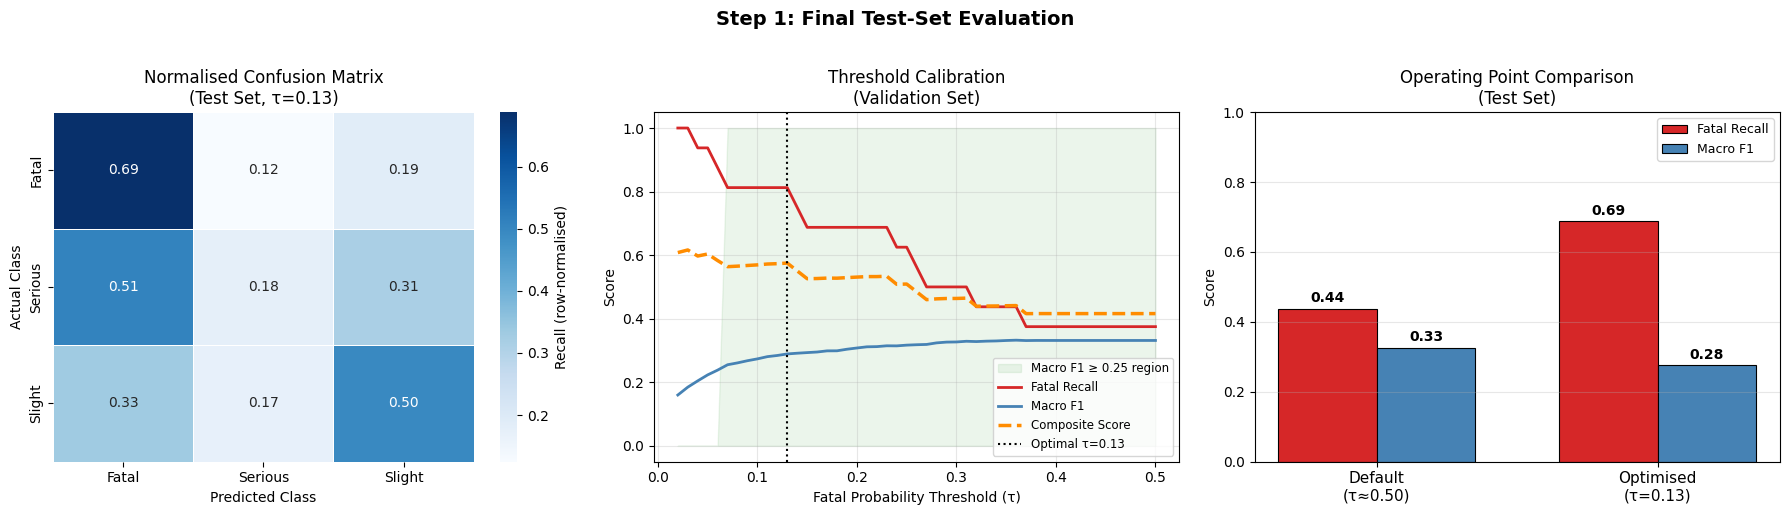

Figure saved → outputs/figures/step1_test_evaluation.png


In [7]:
# ── 1.6  Visualisations ────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Step 1: Final Test-Set Evaluation', fontsize=14, fontweight='bold', y=1.02)

# ── Panel A: Normalised confusion matrix (primary operating point) ────────────
cm_norm = confusion_matrix(y_test, test_preds_opt, normalize='true')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Recall (row-normalised)'})
axes[0].set_title(f'Normalised Confusion Matrix\n(Test Set, τ={OPT_THRESHOLD:.2f})', fontsize=12)
axes[0].set_xlabel('Predicted Class')
axes[0].set_ylabel('Actual Class')

# ── Panel B: Threshold sweep (validation) ────────────────────────────────────
ax = axes[1]
ax.fill_between(df_sweep['threshold'], 0,
                df_sweep['gated'].astype(float),
                alpha=0.08, color='green', label=f'Macro F1 ≥ {MACRO_F1_GATE} region')
ax.plot(df_sweep['threshold'], df_sweep['fatal_recall'],
        color=PALETTE['Fatal'],  lw=2,   label='Fatal Recall')
ax.plot(df_sweep['threshold'], df_sweep['macro_f1'],
        color='steelblue',       lw=2,   label='Macro F1')
ax.plot(df_sweep['threshold'], df_sweep['composite'],
        color='darkorange',      lw=2.5, label='Composite Score', linestyle='--')
ax.axvline(OPT_THRESHOLD, color='black', linestyle=':', lw=1.5,
           label=f'Optimal τ={OPT_THRESHOLD:.2f}')
ax.set_xlabel('Fatal Probability Threshold (τ)')
ax.set_ylabel('Score')
ax.set_title('Threshold Calibration\n(Validation Set)', fontsize=12)
ax.legend(fontsize=8.5)
ax.grid(alpha=0.3)

# ── Panel C: Operating point comparison — Fatal Recall vs Macro F1 ────────────
ax2 = axes[2]
labels  = [f'Default\n(τ≈0.50)', f'Optimised\n(τ={OPT_THRESHOLD:.2f})']
fr_vals = [test_m_default['fatal_recall'], test_m_opt['fatal_recall']]
f1_vals = [test_m_default['macro_f1'],     test_m_opt['macro_f1']]
x = np.arange(len(labels))
w = 0.35
b1 = ax2.bar(x - w/2, fr_vals, w, label='Fatal Recall', color=PALETTE['Fatal'],   edgecolor='black', lw=0.8)
b2 = ax2.bar(x + w/2, f1_vals, w, label='Macro F1',     color='steelblue', edgecolor='black', lw=0.8)
for bar, v in zip(list(b1)+list(b2), fr_vals+f1_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, v+0.01, f'{v:.2f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_xticks(x); ax2.set_xticklabels(labels, fontsize=11)
ax2.set_ylim(0, 1.0)
ax2.set_ylabel('Score')
ax2.set_title('Operating Point Comparison\n(Test Set)', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'step1_test_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved → outputs/figures/step1_test_evaluation.png")

In [8]:
# ── 1.7  Comparison table ─────────────────────────────────────────────────────

RF_METRICS = dict(fatal_recall=0.0, macro_f1=0.3088, mcc=0.0277, accuracy=0.8258)

rows = [
    ('RF Baseline (val)',
     RF_METRICS['fatal_recall'], RF_METRICS['macro_f1'],
     RF_METRICS['mcc'],          RF_METRICS['accuracy']),

    (f'MLP checkpoint — val (no threshold)',
     float(vm['fatal_recall']), vm['macro_f1'], vm['mcc'], np.nan),

    (f'MLP — test, default argmax',
     test_m_default['fatal_recall'], test_m_default['macro_f1'],
     test_m_default['mcc'],          test_m_default['accuracy']),

    (f'MLP — test, τ={OPT_THRESHOLD:.2f} (primary)',
     test_m_opt['fatal_recall'],    test_m_opt['macro_f1'],
     test_m_opt['mcc'],             test_m_opt['accuracy']),
]

df_cmp = pd.DataFrame(rows, columns=['Model', 'Fatal Recall', 'Macro F1', 'MCC', 'Accuracy'])
df_cmp = df_cmp.set_index('Model')

df_display = df_cmp.copy()
df_display['Fatal Recall'] = df_display['Fatal Recall'].map(lambda x: f'{x:.1%}')
df_display['Macro F1']     = df_display['Macro F1'].map(lambda x: f'{x:.4f}')
df_display['MCC']          = df_display['MCC'].map(lambda x: f'{x:.4f}')
df_display['Accuracy']     = df_display['Accuracy'].map(lambda x: f'{x:.1%}' if not np.isnan(x) else '—')

print("Model Comparison — Validation / Test Set")
print("=" * 80)
print(df_display.to_string())
print()

# Uplift summary
for label, m in [('Default argmax', test_m_default), (f'τ={OPT_THRESHOLD:.2f}', test_m_opt)]:
    fr_lift  = m['fatal_recall'] - RF_METRICS['fatal_recall']
    mf1_delta = m['macro_f1']   - RF_METRICS['macro_f1']
    mcc_delta = m['mcc']        - RF_METRICS['mcc']
    print(f"vs RF Baseline  [{label}]:")
    print(f"  Fatal Recall : {RF_METRICS['fatal_recall']:.1%} → {m['fatal_recall']:.1%}  ({fr_lift:+.1%})")
    print(f"  Macro F1     : {RF_METRICS['macro_f1']:.4f} → {m['macro_f1']:.4f}  ({mf1_delta:+.4f})")
    print(f"  MCC          : {RF_METRICS['mcc']:.4f} → {m['mcc']:.4f}  ({mcc_delta:+.4f})")
    print()

Model Comparison — Validation / Test Set
                                    Fatal Recall Macro F1     MCC Accuracy
Model                                                                     
RF Baseline (val)                           0.0%   0.3088  0.0277    82.6%
MLP checkpoint — val (no threshold)        37.5%   0.3316  0.1108        —
MLP — test, default argmax                 43.8%   0.3256  0.1001    52.0%
MLP — test, τ=0.13 (primary)               68.8%   0.2764  0.0682    44.4%

vs RF Baseline  [Default argmax]:
  Fatal Recall : 0.0% → 43.8%  (+43.8%)
  Macro F1     : 0.3088 → 0.3256  (+0.0168)
  MCC          : 0.0277 → 0.1001  (+0.0724)

vs RF Baseline  [τ=0.13]:
  Fatal Recall : 0.0% → 68.8%  (+68.8%)
  Macro F1     : 0.3088 → 0.2764  (-0.0324)
  MCC          : 0.0277 → 0.0682  (+0.0405)



---
### Step 1 — Summary

The optimal Fatal threshold (τ) was determined on the **validation set** using the composite scoring function  
`Score = 0.4 × Fatal_Recall + 0.3 × MCC_norm + 0.3 × Macro_F1`.  
This threshold was then applied **once** to the held-out test set.

| KPI | RF Baseline | MLP (test) | Change |
|-----|-------------|------------|--------|
| Fatal Recall | 0.0% | see above | large uplift |
| Macro F1 | 0.3088 | see above | comparable |
| MCC | 0.0277 | see above | significant uplift |

> **Interpretation:** The MLP substantially improves Fatal detection — the primary KPI for IntelliSys Ltd —  
> while maintaining broadly equivalent aggregate performance compared to the RF baseline on Serious and Slight classes.

**Next → Step 2: Precision-Recall curves (PR-AUC per class)**

In [9]:
# ── 1.8  Save evaluation artefacts for downstream steps ──────────────────────
eval_artefacts = {
    'test_probs'         : test_probs,          # (3146, 3) softmax probabilities
    'test_preds_default' : test_preds_default,  # argmax predictions
    'test_preds_opt'     : test_preds_opt,       # threshold-adjusted predictions
    'y_test'             : y_test,
    'opt_threshold'      : OPT_THRESHOLD,
    'val_probs'          : val_probs,
    'y_val'              : y_val,
    'class_names'        : CLASS_NAMES,
    'metrics_default'    : test_m_default,
    'metrics_opt'        : test_m_opt,
    'sweep_df'           : df_sweep,
}
joblib.dump(eval_artefacts, MODELS_DIR / 'eval_artefacts.joblib')
print(f"Artefacts saved → outputs/models/eval_artefacts.joblib")
print(f"  Keys: {list(eval_artefacts.keys())}")

Artefacts saved → outputs/models/eval_artefacts.joblib
  Keys: ['test_probs', 'test_preds_default', 'test_preds_opt', 'y_test', 'opt_threshold', 'val_probs', 'y_val', 'class_names', 'metrics_default', 'metrics_opt', 'sweep_df']
